             Missing Count  Missing Percentage
deck                   688           77.216611
age                    177           19.865320
embarked                 2            0.224467
embark_town              2            0.224467
survived                 0            0.000000
pclass                   0            0.000000
sex                      0            0.000000
sibsp                    0            0.000000
parch                    0            0.000000
fare                     0            0.000000
class                    0            0.000000
who                      0            0.000000
adult_male               0            0.000000
alive                    0            0.000000
alone                    0            0.000000
Survival Distribution (%):
 survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

Logistic Regression Performance:
Accuracy: 0.8045
Precision: 0.8036
Recall: 0.6522
F1 Score: 0.7200
              precision    recall  f1-score   s

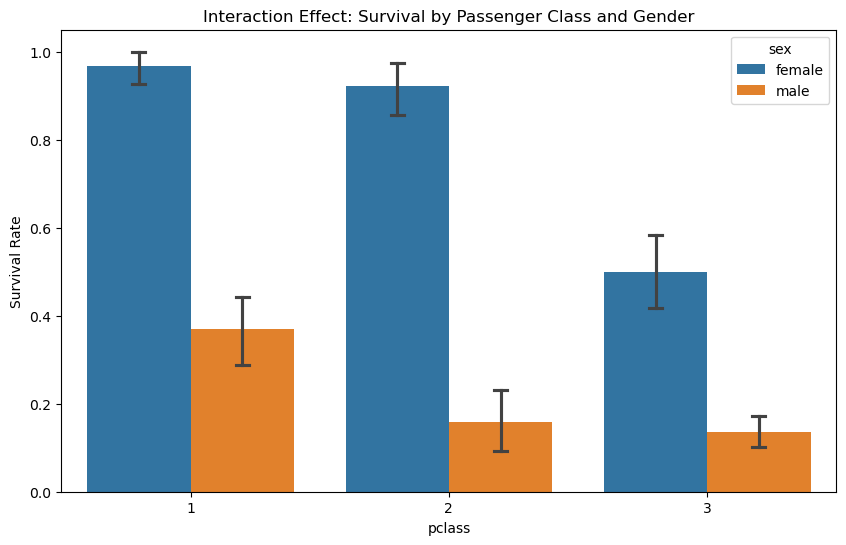

Optimization terminated successfully.
         Current function value: 0.437143
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  889
Model:                          Logit   Df Residuals:                      878
Method:                           MLE   Df Model:                           10
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                  0.3429
Time:                        19:10:55   Log-Likelihood:                -388.62
converged:                       True   LL-Null:                       -591.41
Covariance Type:            nonrobust   LLR p-value:                 6.115e-81
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       3.4935      0.514      6.802      0.000       2.487   

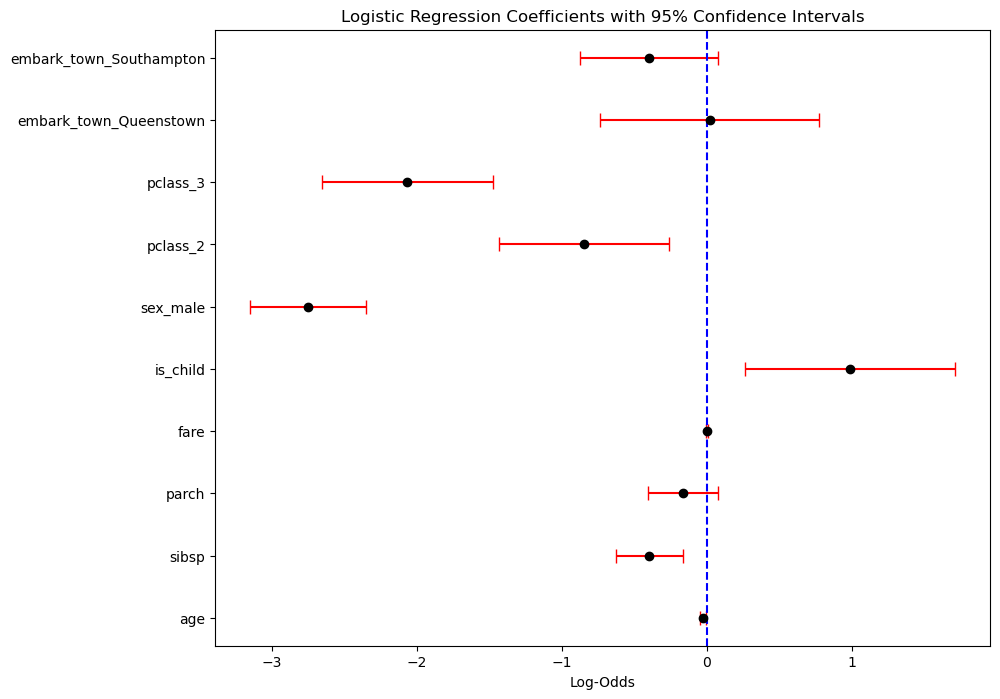

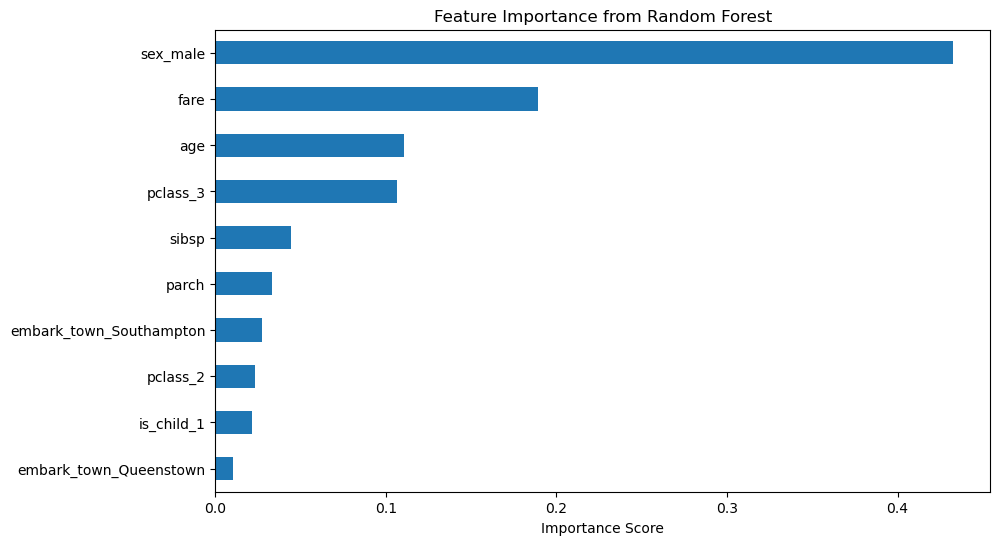

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load dataset
titanic = sns.load_dataset("titanic")

# Assess missing data (used in data audit section)
missing_summary = pd.DataFrame({
    "Missing Count": titanic.isnull().sum(),
    "Missing Percentage": (titanic.isnull().sum() / len(titanic)) * 100
}).sort_values(by="Missing Percentage", ascending=False)
print(missing_summary)

# Check class imbalance in survival
print("Survival Distribution (%):\n", titanic['survived'].value_counts(normalize=True) * 100)

# Select variables used in modeling
data = titanic[['survived', 'sex', 'age', 'pclass', 'sibsp', 'parch', 'fare', 'embark_town']].copy()

# Create child indicator to reflect "children first" assumption
data['is_child'] = (data['age'] < 18).astype(int)

# Define predictors and outcome
X = data.drop('survived', axis=1)
y = data['survived']

# Separate numeric and categorical variables
numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'pclass', 'embark_town', 'is_child']

# Handle missing values and scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # median used due to skewness in age
    ('scaler', StandardScaler())
])

# Encode categorical variables for model use
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Split data (stratified due to class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression model (used for interpretability)
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Random Forest model (used for capturing non-linear patterns)
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
])

# Train and evaluate both models
for name, model in [("Logistic Regression", log_model), ("Random Forest", rf_model)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

# Cross-validation to assess model stability
cv_log = cross_val_score(log_model, X, y, cv=5, scoring='f1')
cv_rf = cross_val_score(rf_model, X, y, cv=5, scoring='f1')

print(f"\nCV F1 Mean - Logistic: {np.mean(cv_log):.4f} (+/- {np.std(cv_log):.4f})")
print(f"CV F1 Mean - Random Forest: {np.mean(cv_rf):.4f} (+/- {np.std(cv_rf):.4f})")

# Visualizing interaction effect (class × gender)
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='pclass', y='survived', hue='sex', capsize=.1)
plt.title("Interaction Effect: Survival by Passenger Class and Gender")
plt.ylabel("Survival Rate")
plt.show()

# Prepare data for statistical inference using statsmodels
data_final = data.dropna(subset=['embark_town'])

data_dummies = pd.get_dummies(
    data_final,
    columns=['sex', 'pclass', 'embark_town'],
    drop_first=True
)

# Median imputation for age (consistent with preprocessing decisions)
data_dummies['age'] = data_dummies['age'].fillna(data_dummies['age'].median())

X_sm = data_dummies.drop('survived', axis=1).astype(float)
y_sm = data_dummies['survived']

X_sm = sm.add_constant(X_sm)

# Logistic regression for coefficient interpretation
logit_res = sm.Logit(y_sm, X_sm).fit()
print(logit_res.summary())

# Confidence interval visualization (shows uncertainty)
summary_df = logit_res.conf_int()
summary_df['Coef'] = logit_res.params
summary_df.columns = ['Lower', 'Upper', 'Coef']
summary_df = summary_df.drop('const')

plt.figure(figsize=(10, 8))
plt.errorbar(summary_df['Coef'], summary_df.index,
             xerr=[summary_df['Coef'] - summary_df['Lower'], summary_df['Upper'] - summary_df['Coef']],
             fmt='o', color='black', ecolor='red', capsize=5)
plt.axvline(x=0, color='blue', linestyle='--')
plt.title("Logistic Regression Coefficients with 95% Confidence Intervals")
plt.xlabel("Log-Odds")
plt.show()

# Feature importance from Random Forest (to assess structural drivers)
rf_model.fit(X_train, y_train)
rf_inner = rf_model.named_steps['classifier']

ohe = rf_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
ohe_features = ohe.get_feature_names_out(categorical_features)

feature_names = numeric_features + list(ohe_features)

importances = pd.Series(rf_inner.feature_importances_, index=feature_names).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance Score")
plt.show()